# 🕌 KHALEEJI-MIND
## A Gulf Arabic Social Cognition Benchmark — Interactive Theory of Mind Evaluation Pipeline

> **Course:** CS-UH 3260 · Artificial Social Intelligence · NYU Abu Dhabi  
> **Dataset:** `KHALEEJI_MIND_balanced_100_cleaned.csv` (80 scenarios, 5 norm categories)

---

### Pipeline Overview

This notebook runs the full KHALEEJI-MIND evaluation pipeline in the following order:

| Step | Section | Description |
|------|---------|-------------|
| 0 | Setup | Install packages and import libraries |
| 1 | Configuration | API keys and model IDs |
| 2 | Data Loading | Load CSV, clean columns, inspect dataset |
| 3 | Preprocessing | Normalize text, build zero-shot prompts |
| 4 | Model Evaluation | Random baseline + GPT-4 + Gemini (zero-shot) |
| 5 | Main Results | Accuracy table across categories, language, ToM order |
| 6 | Chain-of-Thought | CoT prompting evaluation |
| 7 | Cultural Bias | Norm-in-context and western-framing probes |
| 8 | Visualisation | Accuracy bar charts |
| 9 | Error Analysis | Western-centric error rate, severity breakdown |
| 10 | Norm Diagnostic | Zero-shot vs norm-in-context deep comparison |
| 11 | Save Results | Export results CSV |


## Step 0 — Setup

Upgrades `numpy` first (avoids binary incompatibility errors in Colab), then installs all required packages.  
**After running this cell, restart the runtime before continuing.**


In [ ]:
import sys
import subprocess

# Upgrade numpy first to avoid binary incompatibility with other packages
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "numpy>=2.0", "--upgrade"],
    check=True
)

# Install all other required packages
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "openai", "google-generativeai",
     "pandas", "matplotlib", "seaborn",
     "scipy", "scikit-learn", "statsmodels"],
    check=True
)

print("✅ All packages installed.")
print("→ If running in Colab: Runtime → Restart session, then run from Step 1.")


✅ All packages installed.
→ If running in Colab: Runtime → Restart session, then run from Step 1.


## Step 1 — Configuration

Set your API keys and model identifiers here.

- **OpenRouter** is used to call all three models via a unified API endpoint.
- **GPT-4** is accessed via `openai/gpt-4`.
- **Gemini** is accessed via `google/gemini-2.5-flash`.
- **Mistral-7B** is accessed via `mistralai/mistral-7b-instruct-v0.1` as the open-source baseline.
- No mock fallback — all results are real API calls.

In [ ]:
import os

# ── API Keys ─────────────────────────────────────────────────
OPENROUTER_API_KEY = "ADD KEY"
GEMINI_API_KEY     = "ADD KEY"

os.environ["OPENROUTER_API_KEY"] = OPENROUTER_API_KEY
os.environ["GEMINI_API_KEY"]     = GEMINI_API_KEY

# ── Model IDs on OpenRouter ───────────────────────────────────
GPT4_MODEL   = "openai/gpt-4"
GEMINI_MODEL = "google/gemini-2.5-flash"
LLAMA_MODEL = "mistralai/mistral-7b-instruct-v0.1"

print("✅ Configuration ready.")
print(f"   GPT-4 model     : {GPT4_MODEL}")
print(f"   Gemini model    : {GEMINI_MODEL}")
print(f"   Dolphin model   : {LLAMA_MODEL}")


✅ Configuration ready.
   GPT-4 model     : openai/gpt-4
   Gemini model    : google/gemini-2.5-flash
   Dolphin model   : mistralai/mistral-7b-instruct-v0.1


## Step 2 — Data Loading

Loads the cleaned KHALEEJI-MIND dataset and prepares all columns for evaluation.

### What happens here
- Reads the CSV from the path you specify in `CSV_PATH`
- Renames columns to short, consistent internal names
- Normalises the `language` field (`ENG/AR` → `BILINGUAL`)
- Maps `tom_order` strings (`"first"` / `"second"`) to integers (1 / 2)
- Bundles the four answer options into a single `options` dict per row
- Uses the pre-existing `question_text` column directly (no reconstruction needed)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# ── Set path to your CSV ──────────────────────────────────────
# If running locally, set this to the file's absolute or relative path.
# If running in Colab with Google Drive, mount first and use the Drive path.
CSV_PATH = "/content/drive/MyDrive/ASI_FINAL_PROJECT/KHALEEJI_MIND_balanced_100_cleaned.csv"


df = pd.read_csv(CSV_PATH)

# ── Rename columns to short internal names ────────────────────
df = df.rename(columns={
    "scenario_id":               "id",
    "scenario_text":             "scenario",
    "question_text":             "question",
    "correct_answer":            "correct",
    "common_western_misreading": "western_distractor",
})

# ── Normalise language labels ─────────────────────────────────
df["language"] = df["language"].replace({"ENG/AR": "BILINGUAL", "EN/AR": "BILINGUAL"})

# ── Map ToM order strings to integers ────────────────────────
df["tom_order"] = df["tom_order"].map({"first": 1, "second": 2})

# ── Bundle answer options into a dict per row ─────────────────
df["options"] = df.apply(
    lambda r: {"A": r["option_A"], "B": r["option_B"],
               "C": r["option_C"], "D": r["option_D"]},
    axis=1
)

print(f"✅ Loaded {len(df)} scenarios  |  {df['norm_category'].nunique()} norm categories")
print(f"\nnorm_category distribution:")
print(df["norm_category"].value_counts().to_string())
print(f"\nlanguage distribution:")
print(df["language"].value_counts().to_string())
print(f"\ntom_order distribution:")
print(df["tom_order"].value_counts().sort_index().to_string())
print(f"\ncorrect_answer distribution:")
print(df["correct"].value_counts().sort_index().to_string())


✅ Loaded 80 scenarios  |  5 norm categories

norm_category distribution:
norm_category
diyafa                  23
religious_observance    16
hierarchy               15
gender_interaction      15
community_obligation    11

language distribution:
language
EN           31
BILINGUAL    25
AR           24

tom_order distribution:
tom_order
1    41
2    39

correct_answer distribution:
correct
A    20
B    20
C    20
D    20


### Dataset Balance Summary

The final dataset contains **80 scenarios** across **5 norm categories**. The largest category is **diyafa** with 23 scenarios, which is expected because hospitality includes many detailed Emirati سنع practices such as qahwa serving, majlis etiquette, guest reception, and visit-closing cues. The other categories are also represented: religious observance has 16 scenarios, hierarchy and gender interaction each have 15, and community obligation has 11.

The language distribution is reasonably balanced across **English (31)**, **bilingual/code-switched scenarios (25)**, and **Arabic (24)**. This supports evaluation across different linguistic contexts, including the mixed Arabic-English settings common in Gulf communication.

The Theory of Mind split is also balanced, with **41 first-order** and **39 second-order** scenarios. This means the benchmark tests both direct belief inference and more complex reasoning about one person’s understanding of another person’s belief.

Finally, the correct answers are perfectly balanced, with **20 answers each for A, B, C, and D**. This reduces answer-position bias and makes the evaluation more reliable.

## Step 2b — Dataset Overview

A structured summary of the KHALEEJI-MIND benchmark dataset.

### What is KHALEEJI-MIND?

KHALEEJI-MIND is a Theory of Mind (ToM) evaluation benchmark designed to test whether large language models can correctly interpret the mental states, beliefs, and intentions of characters operating within **Gulf Arabic social norms**. Each scenario presents a culturally-specific social situation and asks the model to identify what a focal character truly thinks or feels — while avoiding a plausible Western-centric misreading.

### Dataset Properties

| Property | Value |
|----------|-------|
| Total scenarios | **80** |
| Norm categories | **5** (diyafa, hierarchy, gender_interaction, religious_observance, community_obligation) |
| Languages | EN · AR · BILINGUAL |
| ToM Order 1 (direct mental state) | 41 scenarios |
| ToM Order 2 (belief about belief) | 39 scenarios |
| Answer options per scenario | 4 (A / B / C / D) |
| Random chance baseline | 25% |
| Severity range | 0 (no violation) → 5 (severe violation) |

### Norm Categories

| Category | Count | Description |
|----------|-------|-------------|
| `diyafa` | 23 | Hospitality and guest reception norms |
| `hierarchy` | 15 | Age, rank, and status-based interaction rules |
| `religious_observance` | 16 | Islamic practice and observance etiquette |
| `gender_interaction` | 15 | Gender-separated space and modesty norms |
| `community_obligation` | 11 | Collective duty, neighbourhood, and السنع etiquette |

### Severity Scale

Each scenario carries a `severity` score indicating how serious the social violation in the scenario is:

| Score | Meaning |
|-------|---------|
| 0 | No real violation — character merely misreads a cultural cue |
| 2 | Minor norm breach with minimal social consequence |
| 3 | Moderate violation — socially noticeable and awkward |
| 4 | Serious breach — damages relationships or reputation |
| 5 | Severe violation — significant social or religious transgression |

### Key Design Choices

- Every scenario includes **one culturally correct answer** and **one Western-centric distractor** designed to reflect how a non-Khaleeji observer would misinterpret the situation.
- Scenarios span **first-order** ToM (what does X think?) and **second-order** ToM (what does X think Y believes?).
- Arabic and bilingual scenarios test whether models maintain cultural accuracy across languages.

In [ ]:
# ── Severity distribution ──────────────────────────────────
print("Severity distribution:")
print(df["severity"].value_counts().sort_index().to_string())
print()

# ── Severity by norm category ──────────────────────────────
print("Mean severity by norm category:")
print(df.groupby("norm_category")["severity"].mean().round(2).sort_values(ascending=False).to_string())
print()

# ── ToM order by category ─────────────────────────────────
print("ToM order breakdown by norm category:")
print(df.groupby(["norm_category", "tom_order"]).size().unstack(fill_value=0).to_string())
print()

# ── Language by category ──────────────────────────────────
print("Language distribution by norm category:")
print(df.groupby(["norm_category", "language"]).size().unstack(fill_value=0).to_string())


Severity distribution:
severity
0    46
2     5
3    13
4     9
5     7

Mean severity by norm category:
norm_category
diyafa                  2.09
religious_observance    2.06
community_obligation    1.55
hierarchy               0.93
gender_interaction      0.53

ToM order breakdown by norm category:
tom_order              1   2
norm_category               
community_obligation   4   7
diyafa                12  11
gender_interaction     6   9
hierarchy              9   6
religious_observance  10   6

Language distribution by norm category:
language              AR  BILINGUAL  EN
norm_category                          
community_obligation   2          7   2
diyafa                 3          9  11
gender_interaction     8          4   3
hierarchy              5          3   7
religious_observance   6          2   8


### Severity and Cross-Category Analysis

The severity distribution shows that many scenarios are coded as **0**, meaning no local norm is directly violated; instead, the scenario tests whether an outsider or model misreads a culturally appropriate Emirati behavior. Higher severity values are reserved for cases where an actual breach of سنع occurs, such as mishandling qahwa, disrespecting elders, or violating hospitality expectations.

The highest average severity appears in **diyafa** and **religious observance**, which makes sense because these categories often involve visible social duties, guest treatment, and ritual expectations. A mistake in these areas can create stronger social consequences. In contrast, **gender interaction** and **hierarchy** have lower average severity because many scenarios in these categories focus on outsiders misinterpreting correct local behavior rather than someone committing a serious breach.

The Theory of Mind distribution remains balanced within the dataset, with both first-order and second-order reasoning represented across all norm categories. The language breakdown also shows useful variation: English, Arabic, and bilingual/code-switched scenarios appear across categories, allowing the benchmark to test cultural reasoning across different linguistic contexts.

## Step 2c — Map Western Distractor to Answer Letter

Each scenario has a `western_distractor` field containing the text of the answer option that reflects a typical Western misreading of the situation. This step identifies **which letter (A/B/C/D)** that distractor corresponds to in each row by matching it against the four option texts.

This letter is used later in the error analysis to measure how often models choose the Western-centric wrong answer specifically.


In [ ]:
def find_western_letter(row):
    """Match the western_distractor text to one of the four option letters."""
    misreading = str(row["western_distractor"]).strip().lower()
    best_letter = "A"
    best_score  = 0
    for letter in ["A", "B", "C", "D"]:
        option_text = str(row[f"option_{letter}"]).strip().lower()
        # Score by shared meaningful words (length > 4 to skip stopwords)
        words = [w for w in option_text.split() if len(w) > 4]
        score = sum(1 for w in words if w in misreading)
        if score > best_score:
            best_score  = score
            best_letter = letter
    return best_letter

df["western_letter"] = df.apply(find_western_letter, axis=1)

print("Western distractor letter distribution:")
print(df["western_letter"].value_counts().to_string())
print()
print("✅ Western letter mapping complete.")


Western distractor letter distribution:
western_letter
A    38
B    19
C    12
D    11

✅ Western letter mapping complete.


### Western Distractor Mapping

The **Western distractor** refers to the incorrect answer option that best represents a likely non-local or Western-centric misunderstanding of the scenario. In other words, it is the answer a person unfamiliar with Emirati سنع might choose because they interpret the situation through a different cultural framework.

This step maps the written `western_distractor` explanation to one of the four answer options: **A, B, C, or D**. The function compares the words in each option with the text of the Western misreading and selects the option with the strongest word overlap. This allows the dataset to track not only the correct answer, but also which incorrect option reflects the most likely cultural misunderstanding.

The Western distractor does not need to be balanced across A, B, C, and D because it is not the correct answer key. It is an additional analysis label used to study whether models are attracted to culturally external interpretations.

## Step 3 — Text Preprocessing & Prompt Building

Prepares each scenario for model evaluation.

### What happens here
- **Arabic normalisation**: removes diacritics (tashkeel) and collapses whitespace — models do not need vocalisation marks and they can cause inconsistent tokenisation.
- **English normalisation**: collapses extra whitespace only.
- **Prompt serialisation**: each scenario is formatted into a fixed zero-shot prompt template.

The prompt format is:
```
Scenario: <scenario text>

Question: <question text>

A) <option A>
B) <option B>
C) <option C>
D) <option D>

Answer with only the letter A, B, C, or D.
Answer:
```


In [ ]:
import re
import unicodedata

def normalize_arabic(text):
    """Remove Arabic diacritics and collapse whitespace."""
    text = unicodedata.normalize("NFC", text)
    # Strip tashkeel (diacritic marks)
    text = re.sub(
        "[\u0610-\u061A\u064B-\u065F\u0670\u06D6-\u06DC\u06DF-\u06E4\u06E7-\u06ED]",
        "", text
    )
    return re.sub(r"\s+", " ", text).strip()

def normalize_english(text):
    """Collapse whitespace only."""
    return re.sub(r"\s+", " ", text).strip()

def preprocess_row(row):
    """Apply the correct normaliser based on scenario language."""
    if row["language"] == "AR":
        row["scenario_processed"] = normalize_arabic(row["scenario"])
        row["question_processed"]  = normalize_arabic(row["question"])
    else:
        row["scenario_processed"] = normalize_english(row["scenario"])
        row["question_processed"]  = normalize_english(row["question"])
    return row

df = df.apply(preprocess_row, axis=1)

def build_prompt(row):
    """Build the zero-shot multiple-choice prompt."""
    o = row["options"]
    return (
        f"Scenario: {row['scenario_processed']}\n\n"
        f"Question: {row['question_processed']}\n\n"
        f"A) {o['A']}\nB) {o['B']}\nC) {o['C']}\nD) {o['D']}\n\n"
        "Answer with only the letter A, B, C, or D.\nAnswer:"
    )

df["prompt"] = df.apply(build_prompt, axis=1)

print("✅ Preprocessing complete.")
print(f"   {len(df)} prompts built.")
print("\n--- Sample prompt (first row) ---")
print(df["prompt"].iloc[0])


✅ Preprocessing complete.
   80 prompts built.

--- Sample prompt (first row) ---
Scenario: Fatima arrives at her neighbour Maryam's house as a surprise at 2pm. Maryam opens the door in home clothes, visibly surprised. She welcomes Fatima graciously, smiles warmly, and begins bustling around to make her feel at home. Fatima smiles, assuming Maryam is thrilled by the surprise.

Question: Maryam appears delighted and is bustling around to welcome Fatima. What is actually going on inside Maryam?

A) Maryam is happy that Fatima came without notice because surprise visits are treated as a stronger sign of neighbourly closeness.
B) Maryam is pleased by the visit but worried that Fatima may think the house looks too quiet because it is the afternoon rest period.
C) Maryam feels caught off guard by the surprise visit but continues acting warmly as host.
D) Maryam is embarrassed because she forgot a planned visit and is now trying to make it seem as if she had prepared for Fatima all along.

An

### Prompt Construction Check

Although the original dataset contains metadata columns such as norm category, ToM order, language, severity, cultural explanation, and the correct answer, these fields are intentionally excluded from the model-facing prompt. The prompt only includes the scenario, question, and four answer options because the model should answer based on reasoning rather than seeing the ground-truth labels.

The remaining dataset columns are still preserved in the dataframe and are used later for evaluation, such as checking accuracy, comparing performance by norm category, analyzing first-order versus second-order Theory of Mind, and studying severity effects.

## Step 4 — Model Evaluation Functions

Defines two evaluation functions used throughout the pipeline:

| Function | Description |
|----------|-------------|
| `evaluate_random` | Random baseline — picks A/B/C/D uniformly at random (seed=42) |
| `evaluate_openrouter` | Calls GPT-4, Gemini, or Mistral-7B via OpenRouter API with `temperature=0`, `timeout=45`, and up to 3 retries with exponential back-off on failure |

Both return a `DataFrame` with the same schema: `scenario_id`, `model`, `condition`, `language`, `norm_category`, `tom_order`, `severity`, `violated_norm`, `predicted`, `correct`, `is_correct`, `raw_response`.

In [ ]:
import random, re, time
from openai import OpenAI

def parse_response(raw):
    if not raw:
        return ""
    text = str(raw).strip()

    # Priority 1: explicit "Final Answer: X"
    m = re.findall(r"(?i)final answer\s*[:\-]?\s*([ABCD])\b", text)
    if m: return m[-1].upper()

    # Priority 2: other explicit answer phrases
    for pat in [
        r"(?i)answer\s*[:\-]?\s*([ABCD])\b",
        r"(?i)the correct answer is\s*([ABCD])\b",
        r"(?i)the answer is\s*([ABCD])\b",
        r"(?i)i choose\s*([ABCD])\b",
    ]:
        m = re.findall(pat, text)
        if m: return m[-1].upper()

    # Fallback: last standalone letter
    letters = re.findall(r"\b([ABCD])\b", text)
    return letters[-1].upper() if letters else ""


# ── Random Baseline ───────────────────────────────────────────
def evaluate_random(data):
    random.seed(42)
    results = []
    for _, row in data.iterrows():
        pred = random.choice(["A", "B", "C", "D"])
        results.append({
            "scenario_id":   row["id"],
            "model":         "Random",
            "condition":     "zero_shot",
            "language":      row["language"],
            "norm_category": row["norm_category"],
            "tom_order":     row["tom_order"],
            "severity":      row["severity"],
            "violated_norm": row["violated_norm"],
            "predicted":     pred,
            "correct":       row["correct"],
            "is_correct":    pred == row["correct"],
        })
    return pd.DataFrame(results)


# ── OpenRouter API Evaluation (with retry + timeout) ──────────
def evaluate_openrouter(data, model_name, model_id, prompt_col="prompt"):
    client = OpenAI(
        api_key=OPENROUTER_API_KEY,
        base_url="https://openrouter.ai/api/v1"
    )
    results = []
    print(f"\nRunning {model_name} — {len(data)} scenarios...")

    for i, (_, row) in enumerate(data.iterrows()):
        raw = ""
        for attempt in range(3):                    # retry up to 3x
            try:
                resp = client.chat.completions.create(
                    model=model_id,
                    messages=[{"role": "user", "content": row[prompt_col]}],
                    max_tokens=5,
                    temperature=0,
                    timeout=45,                     # longer than default
                    extra_headers={
                        "HTTP-Referer": "https://github.com/khaleeji-mind",
                        "X-Title":      "KHALEEJI-MIND"
                    }
                )
                raw = resp.choices[0].message.content
                break                               # success — stop retrying
            except Exception as e:
                print(f"  ⚠️  Attempt {attempt+1}/3 failed on {row['id']}: {e}")
                time.sleep(5 * (attempt + 1))       # 5s, 10s, 15s back-off

        pred = parse_response(raw)
        results.append({
            "scenario_id":   row["id"],
            "model":         model_name,
            "condition":     "zero_shot",
            "language":      row["language"],
            "norm_category": row["norm_category"],
            "tom_order":     row["tom_order"],
            "severity":      row["severity"],
            "violated_norm": row["violated_norm"],
            "predicted":     pred,
            "correct":       row["correct"],
            "is_correct":    (pred == row["correct"]) if pred else False,
            "raw_response":  raw,
        })

        if (i + 1) % 10 == 0:
            acc = sum(r["is_correct"] for r in results) / len(results) * 100
            print(f"  {i+1}/{len(data)} done — acc so far: {acc:.1f}%")

        time.sleep(0.8)

    return pd.DataFrame(results)


## Step 4b — Run Zero-Shot Evaluation

Runs all four models (Random, Mistral-7B, Gemini, GPT-4) on the zero-shot prompts in that order. All results are real API calls — no mock fallback. Mistral-7B runs first since it is the most likely to encounter rate limits, allowing any issues to surface early before the more stable frontier model calls.

In [ ]:
# ── Random baseline ───────────────────────────────────────────
random_results = evaluate_random(df)

# ── Mistral-7B first, then Gemini, then GPT-4 ────────────────
llama_results  = evaluate_openrouter(df, "Mistral-7B", LLAMA_MODEL)
gemini_results = evaluate_openrouter(df, "Gemini",     GEMINI_MODEL)
gpt4_results   = evaluate_openrouter(df, "GPT-4",      GPT4_MODEL)

# ── Combine all results ───────────────────────────────────────
all_results = pd.concat(
    [random_results, llama_results, gemini_results, gpt4_results],
    ignore_index=True
)
all_results["condition"] = "zero_shot"

print(f"\n✅ Zero-shot evaluation complete.")
print(f"   Total result rows: {len(all_results)}")
print(f"   Models: {all_results['model'].unique().tolist()}")
print(f"\nAccuracy summary:")
print(all_results.groupby("model")["is_correct"].mean().round(3) * 100)


Running Mistral-7B — 80 scenarios...
  10/80 done — acc so far: 50.0%
  20/80 done — acc so far: 65.0%
  30/80 done — acc so far: 66.7%
  40/80 done — acc so far: 62.5%
  50/80 done — acc so far: 64.0%
  60/80 done — acc so far: 61.7%
  70/80 done — acc so far: 60.0%
  80/80 done — acc so far: 61.3%

Running Gemini — 80 scenarios...
  10/80 done — acc so far: 80.0%
  20/80 done — acc so far: 90.0%
  30/80 done — acc so far: 93.3%
  40/80 done — acc so far: 90.0%
  50/80 done — acc so far: 92.0%
  60/80 done — acc so far: 93.3%
  70/80 done — acc so far: 94.3%
  80/80 done — acc so far: 95.0%

Running GPT-4 — 80 scenarios...
  10/80 done — acc so far: 80.0%
  20/80 done — acc so far: 90.0%
  30/80 done — acc so far: 93.3%
  40/80 done — acc so far: 90.0%
  50/80 done — acc so far: 92.0%
  60/80 done — acc so far: 93.3%
  70/80 done — acc so far: 94.3%
  80/80 done — acc so far: 95.0%

✅ Zero-shot evaluation complete.
   Total result rows: 320
   Models: ['Random', 'Mistral-7B', 'Gemini

### Zero-Shot Evaluation Results

The zero-shot evaluation was completed across **80 scenarios** for four baselines/models: Random, Mistral-7B, Gemini, and GPT-4. The total result table contains **320 rows**, which is correct because each of the 80 scenarios was evaluated once per model.

The results show a clear performance gap between model types. The random baseline achieved **27.5% accuracy**, which is close to the expected chance level for a four-option multiple-choice task. Mistral-7B performed better than chance at **61.2%**, showing that it can capture some cultural and social reasoning patterns, but still struggles with many Emirati-specific norms.

Gemini and GPT-4 both achieved **95.0% accuracy**, indicating very strong zero-shot performance on the benchmark. This suggests that larger frontier models are much better at inferring the intended cultural and Theory-of-Mind reasoning from the scenario and answer options. However, because Gemini and GPT-4 produced identical accuracy scores, their outputs should be checked to confirm that the two models were evaluated separately and that the same predictions were not accidentally reused.

Overall, the zero-shot results suggest that KHALEEJI-MIND is challenging for smaller models, while stronger models perform very well when given clear multiple-choice cultural reasoning scenarios.

## Step 5 — Main Results Table

Prints a full accuracy breakdown for all four models (GPT-4, Gemini, Mistral-7B, Random) across:

- **Overall** accuracy
- **Per norm-category** accuracy (diyafa, hierarchy, gender interaction, religious observance, community obligation)
- **Per language** (EN, BILINGUAL, AR)
- **Per ToM order** (first-order vs second-order)

Random chance on a 4-choice task is theoretically **25%**. The random baseline (seed=42) scored **27.5%** on this dataset due to normal sampling variation at n=80.

In [ ]:
CATS = ["diyafa", "hierarchy", "gender_interaction",
        "religious_observance", "community_obligation"]

def acc(df_sub):
    return df_sub["is_correct"].mean() * 100 if len(df_sub) > 0 else float("nan")

print("=" * 100)
print(f"KHALEEJI-MIND RESULTS  (n={len(df)} scenarios, zero-shot)")
print("=" * 100)
print(
    f"{'Model':<14} {'Overall':>8} {'Diyafa':>8} {'Hierarchy':>10} "
    f"{'Gender':>8} {'Religious':>10} {'CommObl':>9} "
    f"{'EN':>6} {'Bilin':>7} {'AR':>6} "
    f"{'Ord-1':>7} {'Ord-2':>7}"
)
print("-" * 100)

for model in ["GPT-4", "Gemini", "Mistral-7B", "Random"]:
    m    = all_results[all_results["model"] == model]
    en   = m[m["language"] == "EN"]
    bili = m[m["language"] == "BILINGUAL"]
    ar   = m[m["language"] == "AR"]
    print(
        f"{model:<14} "
        f"{acc(m):>7.1f}% "
        f"{acc(m[m.norm_category=='diyafa']):>7.1f}% "
        f"{acc(m[m.norm_category=='hierarchy']):>9.1f}% "
        f"{acc(m[m.norm_category=='gender_interaction']):>7.1f}% "
        f"{acc(m[m.norm_category=='religious_observance']):>9.1f}% "
        f"{acc(m[m.norm_category=='community_obligation']):>8.1f}% "
        f"{acc(en):>5.1f}% "
        f"{acc(bili):>6.1f}% "
        f"{acc(ar):>5.1f}% "
        f"{acc(m[m.tom_order==1]):>6.1f}% "
        f"{acc(m[m.tom_order==2]):>6.1f}%"
    )

print("=" * 100)
print("Theoretical chance = 25.0% | Random baseline (seed=42) = 27.5% | EN = English-only | Bilin = EN/AR bilingual | AR = Arabic-only")

KHALEEJI-MIND RESULTS  (n=80 scenarios, zero-shot)
Model           Overall   Diyafa  Hierarchy   Gender  Religious   CommObl     EN   Bilin     AR   Ord-1   Ord-2
----------------------------------------------------------------------------------------------------
GPT-4             95.0%    91.3%      93.3%   100.0%     100.0%     90.9%  96.8%   92.0%  95.8%   92.7%   97.4%
Gemini            95.0%    91.3%      86.7%   100.0%     100.0%    100.0%  96.8%   96.0%  91.7%   92.7%   97.4%
Mistral-7B        61.3%    65.2%      60.0%    60.0%      56.2%     63.6%  54.8%   76.0%  54.2%   65.9%   56.4%
Random            27.5%    17.4%      26.7%    33.3%      31.2%     36.4%  25.8%   36.0%  20.8%   24.4%   30.8%
Chance baseline = 25.0% | EN = English-only | Bilin = EN/AR bilingual | AR = Arabic-only


### Zero-Shot Results Summary

The zero-shot evaluation was run on **80 KHALEEJI-MIND scenarios** across four systems: Random, Mistral-7B, Gemini, and GPT-4. The random baseline achieved **27.5%**, which is close to the expected **25% chance level** for a four-option multiple-choice task.

Both **GPT-4** and **Gemini** performed very strongly, each reaching **95.0% overall accuracy**. Their performance was especially high in **gender interaction** and **religious observance**, where both reached **100% accuracy**. GPT-4 was slightly stronger on hierarchy, while Gemini was stronger on community obligation.

**Mistral-7B** achieved **61.3% accuracy**, performing clearly above chance but far below GPT-4 and Gemini. Its strongest performance was on bilingual scenarios at **76.0%**, while its Arabic-only and English-only performance were lower. This suggests that smaller models can capture some cultural reasoning patterns, but struggle more with subtle Emirati سنع and Theory-of-Mind cues.

Across ToM order, GPT-4 and Gemini performed slightly better on **second-order ToM** than first-order ToM, while Mistral-7B showed the opposite pattern. Overall, the results suggest that KHALEEJI-MIND is challenging for smaller models but mostly solvable for stronger frontier models in zero-shot multiple-choice form.

## Step 6 — Chain-of-Thought Prompting Evaluation

Repeats the evaluation with a **chain-of-thought (CoT)** instruction added to each prompt for all three models (GPT-4, Gemini, Mistral-7B).

Instead of asking for only a letter, the model is told to reason briefly in 2–3 sentences about the social and cultural context, then produce its answer in a strict format:

> *"Final Answer: \<A, B, C, or D\>"*

This allows `max_tokens=400` so the model can reason before committing to an answer. The strict final-answer format ensures reliable parsing even when the model produces extended reasoning. The key question is whether encouraging explicit reasoning improves performance on culturally-grounded ToM tasks — and whether the effect differs across frontier and open-source models.

In [ ]:
def build_cot_prompt(row):
    """Build a chain-of-thought prompt with a strict final-answer format."""
    o = row["options"]
    return (
        f"Scenario: {row['scenario_processed']}\n\n"
        f"Question: {row['question_processed']}\n\n"
        f"A) {o['A']}\nB) {o['B']}\nC) {o['C']}\nD) {o['D']}\n\n"
        "Reason briefly in 2-3 sentences about the social and cultural context.\n"
        "Do not mention option letters during your reasoning.\n"
        "At the very end, write your answer exactly in this format:\n"
        "Final Answer: <A, B, C, or D>"
    )

df["cot_prompt"] = df.apply(build_cot_prompt, axis=1)

def evaluate_cot(data, model_name, model_id):
    """Run chain-of-thought evaluation via OpenRouter with retry logic."""
    client = OpenAI(
        api_key=OPENROUTER_API_KEY,
        base_url="https://openrouter.ai/api/v1"
    )
    results = []
    print(f"\nRunning {model_name} CoT — {len(data)} scenarios...")
    for i, (_, row) in enumerate(data.iterrows()):
        raw = ""
        for attempt in range(3):
            try:
                resp = client.chat.completions.create(
                    model=model_id,
                    messages=[{"role": "user", "content": row["cot_prompt"]}],
                    max_tokens=400,
                    temperature=0,
                    timeout=45,
                    extra_headers={
                        "HTTP-Referer": "https://github.com/khaleeji-mind",
                        "X-Title":      "KHALEEJI-MIND"
                    }
                )
                raw = resp.choices[0].message.content
                break
            except Exception as e:
                print(f"  ⚠️  Attempt {attempt+1}/3 failed on {row['id']}: {e}")
                time.sleep(5 * (attempt + 1))

        pred = parse_response(raw)
        results.append({
            "scenario_id":   row["id"],
            "model":         model_name,
            "condition":     "chain_of_thought",
            "language":      row["language"],
            "norm_category": row["norm_category"],
            "tom_order":     row["tom_order"],
            "severity":      row["severity"],
            "violated_norm": row["violated_norm"],
            "predicted":     pred,
            "correct":       row["correct"],
            "is_correct":    (pred == row["correct"]) if pred else False,
            "raw_response":  raw,
        })
        if (i + 1) % 10 == 0:
            acc_so_far = sum(r["is_correct"] for r in results) / len(results) * 100
            print(f"  {i+1}/{len(data)} done — acc so far: {acc_so_far:.1f}%")
        time.sleep(0.8)

    return pd.DataFrame(results)

cot_gpt4    = evaluate_cot(df, "GPT-4",      GPT4_MODEL)
cot_gemini  = evaluate_cot(df, "Gemini",     GEMINI_MODEL)
cot_mistral = evaluate_cot(df, "Mistral-7B", LLAMA_MODEL)

print("\n✅ Chain-of-thought evaluation complete.")



Running GPT-4 CoT — 80 scenarios...
  10/80 done — acc so far: 90.0%
  20/80 done — acc so far: 95.0%
  30/80 done — acc so far: 96.7%
  40/80 done — acc so far: 95.0%
  50/80 done — acc so far: 96.0%
  60/80 done — acc so far: 96.7%
  70/80 done — acc so far: 97.1%
  80/80 done — acc so far: 97.5%

Running Gemini CoT — 80 scenarios...
  10/80 done — acc so far: 90.0%
  20/80 done — acc so far: 95.0%
  30/80 done — acc so far: 96.7%
  40/80 done — acc so far: 92.5%
  50/80 done — acc so far: 94.0%
  60/80 done — acc so far: 95.0%
  70/80 done — acc so far: 95.7%
  80/80 done — acc so far: 96.2%

Running Mistral-7B CoT — 80 scenarios...
  10/80 done — acc so far: 70.0%
  20/80 done — acc so far: 60.0%
  30/80 done — acc so far: 63.3%
  40/80 done — acc so far: 65.0%
  50/80 done — acc so far: 70.0%
  60/80 done — acc so far: 65.0%
  70/80 done — acc so far: 64.3%
  80/80 done — acc so far: 66.2%

✅ Chain-of-thought evaluation complete.


### Chain-of-Thought Evaluation Summary

The chain-of-thought prompting evaluation was completed for **80 scenarios** across GPT-4, Gemini, and Mistral-7B. Compared with the zero-shot setting, all three models improved when given a reasoning-oriented prompt.

**GPT-4** achieved the highest accuracy at **97.5%**, improving from its zero-shot score of **95.0%**. This suggests that adding an explicit reasoning step helped it resolve a small number of culturally subtle cases that it missed in the direct-answer setting.

**Gemini** also performed strongly, reaching **96.2%**, slightly above its zero-shot accuracy of **95.0%**. The improvement is smaller than GPT-4’s, but it still shows that structured reasoning can help with Emirati cultural and Theory-of-Mind interpretation.

**Mistral-7B** improved from **61.3%** in zero-shot to **66.2%** with chain-of-thought prompting. This is the largest relative gain among the models, suggesting that smaller models benefit more from being guided to reason through the scenario before answering. However, its performance remains much lower than GPT-4 and Gemini, showing that many KHALEEJI-MIND scenarios still require cultural knowledge and social inference that smaller models struggle to capture.

Overall, chain-of-thought prompting improved performance across all tested models, with the strongest final performance coming from GPT-4 and Gemini. The results suggest that reasoning prompts help, but model capacity still plays a major role in culturally grounded Theory-of-Mind tasks.

## Step 7 — Cultural Bias Analysis: Norm-in-Context Probe

One additional prompt condition is used to diagnose **where model failures come from**:

### Condition — Norm-in-Context

The `cultural_explanation` field from the dataset is prepended to the prompt **before** the scenario for all three models (GPT-4, Gemini, Mistral-7B).

- **If accuracy rises sharply** → models lack cultural knowledge (knowledge gap)
- **If accuracy stays flat** → models have a reasoning or bias problem that knowledge alone cannot fix

**Result:** Mistral-7B shows a +13.7 percentage-point gain (61.3% → 75.0%), indicating knowledge-driven failures. GPT-4 gains only +3.8pp and Gemini +1.2pp, indicating their errors reflect persistent reasoning biases that cultural context alone cannot resolve. This asymmetry is the study's most theoretically significant finding.

In [ ]:
def build_norm_prompt(row):
    """Prepend the cultural explanation to the standard prompt."""
    o = row["options"]
    return (
        f"Cultural context: {row['cultural_explanation']}\n\n"
        f"Scenario: {row['scenario_processed']}\n\n"
        f"Question: {row['question_processed']}\n\n"
        f"A) {o['A']}\nB) {o['B']}\nC) {o['C']}\nD) {o['D']}\n\n"
        "Answer with only the letter A, B, C, or D.\nAnswer:"
    )

def build_western_prompt(row):
    """Rephrase the prompt as if it is set in a Western social context."""
    o = row["options"]
    return (
        "The following scenario takes place in a Western social context.\n\n"
        f"Scenario: {row['scenario_processed']}\n\n"
        f"Question: {row['question_processed']}\n\n"
        f"A) {o['A']}\nB) {o['B']}\nC) {o['C']}\nD) {o['D']}\n\n"
        "Answer with only the letter A, B, C, or D.\nAnswer:"
    )

df["norm_prompt"]    = df.apply(build_norm_prompt,    axis=1)
df["western_prompt"] = df.apply(build_western_prompt, axis=1)

print("✅ Norm-in-context and Western-framing prompts built.")
print("\n--- Sample norm-in-context prompt (first row, first 400 chars) ---")
print(df["norm_prompt"].iloc[0][:400])


✅ Norm-in-context and Western-framing prompts built.

--- Sample norm-in-context prompt (first row, first 400 chars) ---
Cultural context: In customary Emirati سنع, guests are expected to call before visiting so the host has time to prepare the house, dress appropriately, and receive them properly. The afternoon after Dhuhr is also often treated as private rest time. Maryam's warm welcome does not mean the timing was easy for her; she is preserving hospitality while internally feeling caught off guard by the surpris


### Norm-in-Context and Western-Framing Prompt Construction

This step builds two additional prompt conditions for comparison. The **norm-in-context** prompt gives the model explicit cultural background before asking it to answer the scenario. This tests whether model performance improves when the relevant Emirati سنع rule is made visible instead of requiring the model to infer it on its own.

The **Western-framing** prompt adds a likely non-local or Western-centric interpretation of the situation. This is used to test whether models become more attracted to culturally external explanations when that framing is made salient.

These prompts are not the same as the zero-shot condition. Zero-shot tests what the model can infer from the scenario alone, while norm-in-context and Western-framing prompts test how model reasoning changes when extra cultural or misleading interpretive context is introduced.

### Step 7b — Run Norm-in-Context Evaluation

Calls GPT-4, Gemini, and Mistral-7B with the `norm_prompt` (cultural explanation prepended before the scenario).

In [ ]:
print("Running GPT-4 norm-in-context...")
norm_gpt4    = evaluate_openrouter(df, "GPT-4",      GPT4_MODEL,   prompt_col="norm_prompt")

print("\nRunning Gemini norm-in-context...")
norm_gemini  = evaluate_openrouter(df, "Gemini",     GEMINI_MODEL, prompt_col="norm_prompt")

print("\nRunning Mistral-7B norm-in-context...")
norm_mistral = evaluate_openrouter(df, "Mistral-7B", LLAMA_MODEL,  prompt_col="norm_prompt")

norm_results = pd.concat([norm_gpt4, norm_gemini, norm_mistral], ignore_index=True)
norm_results["condition"] = "norm_in_context"

print(f"\n✅ Norm-in-context evaluation complete — {len(norm_results)} result rows.")

Running GPT-4 norm-in-context...

Running GPT-4 — 80 scenarios...
  10/80 done — acc so far: 90.0%
  20/80 done — acc so far: 95.0%
  30/80 done — acc so far: 96.7%
  40/80 done — acc so far: 97.5%
  50/80 done — acc so far: 98.0%
  60/80 done — acc so far: 98.3%
  70/80 done — acc so far: 98.6%
  80/80 done — acc so far: 98.8%

Running Gemini norm-in-context...

Running Gemini — 80 scenarios...
  10/80 done — acc so far: 90.0%
  20/80 done — acc so far: 95.0%
  30/80 done — acc so far: 96.7%
  40/80 done — acc so far: 92.5%
  50/80 done — acc so far: 94.0%
  60/80 done — acc so far: 95.0%
  70/80 done — acc so far: 95.7%
  80/80 done — acc so far: 96.2%

Running Mistral-7B norm-in-context...

Running Mistral-7B — 80 scenarios...
  10/80 done — acc so far: 80.0%
  20/80 done — acc so far: 85.0%
  30/80 done — acc so far: 86.7%
  40/80 done — acc so far: 82.5%
  50/80 done — acc so far: 82.0%
  60/80 done — acc so far: 76.7%
  70/80 done — acc so far: 77.1%
  80/80 done — acc so far: 75

### Norm-in-Context Evaluation Summary

The norm-in-context evaluation was completed for **80 scenarios** across GPT-4, Gemini, and Mistral-7B. In this condition, the model was given the relevant Emirati cultural explanation before answering, so the task tested whether explicit cultural context improves performance.

**GPT-4** achieved the highest score at **98.8%**, improving from **95.0%** in zero-shot and **97.5%** with chain-of-thought prompting. This suggests that GPT-4 benefits from explicit cultural grounding and can use the provided norm context effectively.

**Gemini** reached **96.2%**, which is slightly higher than its zero-shot score of **95.0%**. However, this result is identical to its chain-of-thought score, so the outputs should be checked to make sure the norm-in-context prompt was actually used and not accidentally reused from the CoT condition.

**Mistral-7B** showed the largest improvement, rising from **61.3%** in zero-shot to **75.0%** with norm-in-context prompting. This suggests that smaller models struggle more when they must infer Emirati سنع implicitly, but improve significantly when the cultural rule is made explicit.

Overall, norm-in-context prompting improved model performance, especially for Mistral-7B. This supports the idea that some model errors come from missing cultural background knowledge rather than from multiple-choice reasoning alone.

### Step 7c — Three-Condition Comparison Table

Compares zero-shot, chain-of-thought, and norm-in-context accuracy for each model overall and broken down by norm category.


In [ ]:
cot_df = pd.concat([cot_gpt4, cot_gemini, cot_mistral], ignore_index=True)

print("=" * 72)
print("THREE-CONDITION COMPARISON: Zero-Shot vs CoT vs Norm-in-Context")
print("=" * 72)
print(
    f"{'Model':<15} {'Zero-Shot':>10} {'CoT':>8} {'CoT Δ':>8} "
    f"{'Norm-Context':>13} {'Norm Δ':>8}"
)
print("-" * 72)

for model in ["GPT-4", "Gemini", "Mistral-7B"]:
    zs = all_results[(all_results.model == model) & (all_results.condition == "zero_shot")]["is_correct"].mean() * 100
    ct = cot_df[cot_df.model == model]["is_correct"].mean() * 100
    nc = norm_results[norm_results.model == model]["is_correct"].mean() * 100
    print(f"{model:<15} {zs:>9.1f}%  {ct:>7.1f}%  {ct-zs:>+7.1f}%  {nc:>12.1f}%  {nc-zs:>+7.1f}%")

print("=" * 72)
print("\nPer-category CoT Δ:")
print("-" * 55)
for model in ["GPT-4", "Gemini", "Mistral-7B"]:
    print(f"\n  {model}:")
    for cat in CATS:
        zs = all_results[
            (all_results.model == model) & (all_results.condition == "zero_shot") &
            (all_results.norm_category == cat)
        ]["is_correct"].mean() * 100
        ct = cot_df[
            (cot_df.model == model) & (cot_df.norm_category == cat)
        ]["is_correct"].mean() * 100
        print(f"    {cat:<28} {zs:.1f}% → {ct:.1f}%  ({ct-zs:+.1f}%)")


THREE-CONDITION COMPARISON: Zero-Shot vs CoT vs Norm-in-Context
Model            Zero-Shot      CoT    CoT Δ  Norm-Context   Norm Δ
------------------------------------------------------------------------
GPT-4                95.0%     97.5%     +2.5%          98.8%     +3.8%
Gemini               95.0%     96.2%     +1.2%          96.2%     +1.2%
Mistral-7B           61.3%     66.2%     +5.0%          75.0%    +13.7%

Per-category CoT Δ:
-------------------------------------------------------

  GPT-4:
    diyafa                       91.3% → 95.7%  (+4.3%)
    hierarchy                    93.3% → 93.3%  (+0.0%)
    gender_interaction           100.0% → 100.0%  (+0.0%)
    religious_observance         100.0% → 100.0%  (+0.0%)
    community_obligation         90.9% → 100.0%  (+9.1%)

  Gemini:
    diyafa                       91.3% → 95.7%  (+4.3%)
    hierarchy                    86.7% → 86.7%  (+0.0%)
    gender_interaction           100.0% → 100.0%  (+0.0%)
    religious_observance  

### Three-Condition Comparison

The three-condition comparison shows that adding reasoning or cultural context improves performance across all models, but the size of the improvement differs by model.

**GPT-4** starts very high in zero-shot at **95.0%** and improves to **97.5%** with chain-of-thought prompting. It reaches its best performance under norm-in-context prompting at **98.8%**, suggesting that explicit Emirati cultural context helps resolve the few remaining difficult cases.

**Gemini** also starts high at **95.0%** and improves slightly to **96.2%** with both chain-of-thought and norm-in-context prompting. The smaller gain suggests that Gemini was already able to infer most of the relevant cultural cues from the scenario alone, though the identical CoT and norm-context scores should be interpreted cautiously.

**Mistral-7B** shows the largest improvement. It rises from **61.3%** in zero-shot to **66.2%** with chain-of-thought, then to **75.0%** with norm-in-context prompting. This suggests that smaller models benefit strongly when the cultural rule is made explicit, meaning many of their zero-shot errors likely come from missing Emirati سنع knowledge rather than from the multiple-choice format itself.

At the category level, chain-of-thought prompting helped GPT-4 most on **community obligation** and **diyafa**. Gemini improved mainly on **diyafa**, while already scoring perfectly on several other categories. Mistral-7B improved on most categories, especially **religious observance** and **gender interaction**, but dropped sharply on **community obligation**. This suggests that CoT can help smaller models reason through some cultural domains, but it may also introduce confusion when the model overthinks socially layered community-duty scenarios.

Overall, the results show that **norm-in-context prompting is the strongest intervention**, especially for the smaller model. The benchmark therefore captures both cultural knowledge gaps and Theory-of-Mind reasoning difficulty.

In [ ]:
for name, df_cot in [("GPT-4", cot_gpt4), ("Gemini", cot_gemini), ("Mistral-7B", cot_mistral)]:
    print("\n" + "="*80)
    print(name, "wrong CoT examples")
    print("="*80)

    wrong = df_cot[df_cot["is_correct"] == False]

    print("Number wrong:", len(wrong))
    print("Predicted distribution:")
    print(df_cot["predicted"].value_counts(dropna=False))

    display(wrong[[
        "scenario_id",
        "norm_category",
        "tom_order",
        "language",
        "correct",
        "predicted"
    ]].head(20))


GPT-4 wrong CoT examples
Number wrong: 2
Predicted distribution:
predicted
C    22
D    20
B    20
A    18
Name: count, dtype: int64


,scenario_id,norm_category,tom_order,language,correct,predicted
6,KM_D07,diyafa,2,EN,A,C
34,KM_H19,hierarchy,1,AR,A,C



Gemini wrong CoT examples
Number wrong: 3
Predicted distribution:
predicted
C    23
D    20
B    20
A    17
Name: count, dtype: int64


,scenario_id,norm_category,tom_order,language,correct,predicted
6,KM_D07,diyafa,2,EN,A,C
33,KM_H18,hierarchy,1,AR,A,C
34,KM_H19,hierarchy,1,AR,A,C



Mistral-7B wrong CoT examples
Number wrong: 27
Predicted distribution:
predicted
C    24
B    17
A    14
D    14
     11
Name: count, dtype: int64


,scenario_id,norm_category,tom_order,language,correct,predicted
1,KM_D02,diyafa,1,EN,D,
5,KM_D06,diyafa,2,EN,C,B
9,KM_D11,diyafa,1,BILINGUAL,B,D
13,KM_D15,diyafa,1,BILINGUAL,B,C
14,KM_D17,diyafa,2,BILINGUAL,C,B
15,KM_D18,diyafa,2,EN,D,
18,KM_C7,community_obligation,1,BILINGUAL,D,C
19,KM_D23,diyafa,1,AR,A,C
24,KM_H03,hierarchy,1,EN,A,C
25,KM_H04,hierarchy,2,EN,B,C


### Chain-of-Thought Error Analysis

The chain-of-thought error analysis shows that GPT-4 and Gemini made very few mistakes, while Mistral-7B produced a much larger number of incorrect or missing predictions.

**GPT-4** answered incorrectly on only **2 out of 80 scenarios**. Its errors appeared in **KM_D07** and **KM_H19**, suggesting that even a strong model can still miss subtle hospitality or hierarchy cues when the culturally correct interpretation depends on indirect social meaning.

**Gemini** answered incorrectly on **3 out of 80 scenarios**. Two of its errors overlap with GPT-4, including **KM_D07** and **KM_H19**, while it also missed **KM_H18**. This overlap suggests that some scenarios are genuinely difficult even for frontier models, especially when the correct answer depends on reading silence, respect, or indirect discomfort.

**Mistral-7B** made **27 errors**, showing a much weaker ability to handle culturally grounded Theory-of-Mind reasoning. Its mistakes appear across diyafa, hierarchy, gender interaction, and religious observance. This supports the broader result that smaller models struggle more with Emirati سنع, especially when the task requires interpreting unstated social expectations rather than surface-level wording.

One important technical note is that Mistral-7B produced several blank predictions. These should be treated carefully because they may reflect output-format or parsing failures, not only reasoning errors. Still, the overall pattern shows that Mistral-7B is much less reliable than GPT-4 and Gemini on this benchmark.

In [ ]:

for name, df_cot in [("GPT-4", cot_gpt4), ("Gemini", cot_gemini), ("Mistral-7B", cot_mistral)]:
    print("\n" + "="*80)
    print(name, "RAW wrong CoT examples")
    print("="*80)

    wrong = df_cot[df_cot["is_correct"] == False].head(10)

    for _, row in wrong.iterrows():
        print("\n" + "-"*80)
        print("ID:", row["scenario_id"])
        print("Correct:", row["correct"], "| Parsed predicted:", row["predicted"])
        print("RAW RESPONSE:")
        print(row.get("raw_response", "NO RAW RESPONSE COLUMN"))



GPT-4 RAW wrong CoT examples

--------------------------------------------------------------------------------
ID: KM_D07
Correct: A | Parsed predicted: C
RAW RESPONSE:
In many social and cultural contexts, particularly in more traditional or hospitality-focused settings, the host often waits for guests to begin eating before sitting down themselves. Mariam staying by the table was likely a subtle signal that she was waiting for everyone to gather and start the meal. The cousin, however, misinterpreted this as an indication that there was no urgency to begin eating and continued the conversation instead.

Final Answer: C

--------------------------------------------------------------------------------
ID: KM_H19
Correct: A | Parsed predicted: C
RAW RESPONSE:
في العديد من الثقافات، وخاصة في المجتمعات التي تعطي أهمية كبيرة لاحترام الكبار، قد يُعتبر تصحيح الابن لوالده أمام الضيوف تصرفاً غير لائق أو تقليلاً من احترام الوالد، حتى لو كان التصحيح صحيحاً. جاك، كصديق أجنبي، قد لا يكون مدركاً ل

### Chain-of-Thought Raw Error Analysis

The raw CoT error outputs show that GPT-4 and Gemini made very few mistakes, while Mistral-7B struggled more often and sometimes failed to return a clean answer letter.

However, the raw responses also reveal an important dataset-quality issue: not every “wrong” answer is necessarily a pure reasoning failure. In several cases, the model’s explanation shows that it understood the cultural norm correctly, but the selected option was ambiguous or too close to another answer choice.

For example, both GPT-4 and Gemini missed **KM_D07**, but their reasoning correctly identified that the host was waiting for guests to move toward the meal. This suggests that KM_D07 may have an answer-option ambiguity rather than a clear model failure. Similarly, **KM_H19** was missed by both GPT-4 and Gemini because the distinction between “the father would appreciate the correction” and “the father would feel proud of his son’s accuracy” is subtle and may be too close. Gemini’s error on **KM_H18** also suggests possible overlap between the options describing the father as personally difficult versus physically tired or uncomfortable.

Mistral-7B made many more errors and also produced several blank or poorly formatted predictions. These should be interpreted carefully because some failures reflect answer-format parsing issues, not only cultural reasoning errors. Still, the broader pattern shows that Mistral-7B is much less reliable on culturally grounded Theory-of-Mind tasks than GPT-4 and Gemini.

Overall, this analysis is useful because it identifies both model weaknesses and dataset refinement points. The strongest benchmark items are those where the model’s reasoning is clearly wrong, not where the model gives a culturally reasonable explanation but chooses a competing ambiguous option.

## Step 8 — Visualisation

Produces two bar charts:
1. **Overall accuracy by model** — compared against the 25% chance baseline
2. **Per norm-category accuracy** — side-by-side bars for each model across all five norm categories


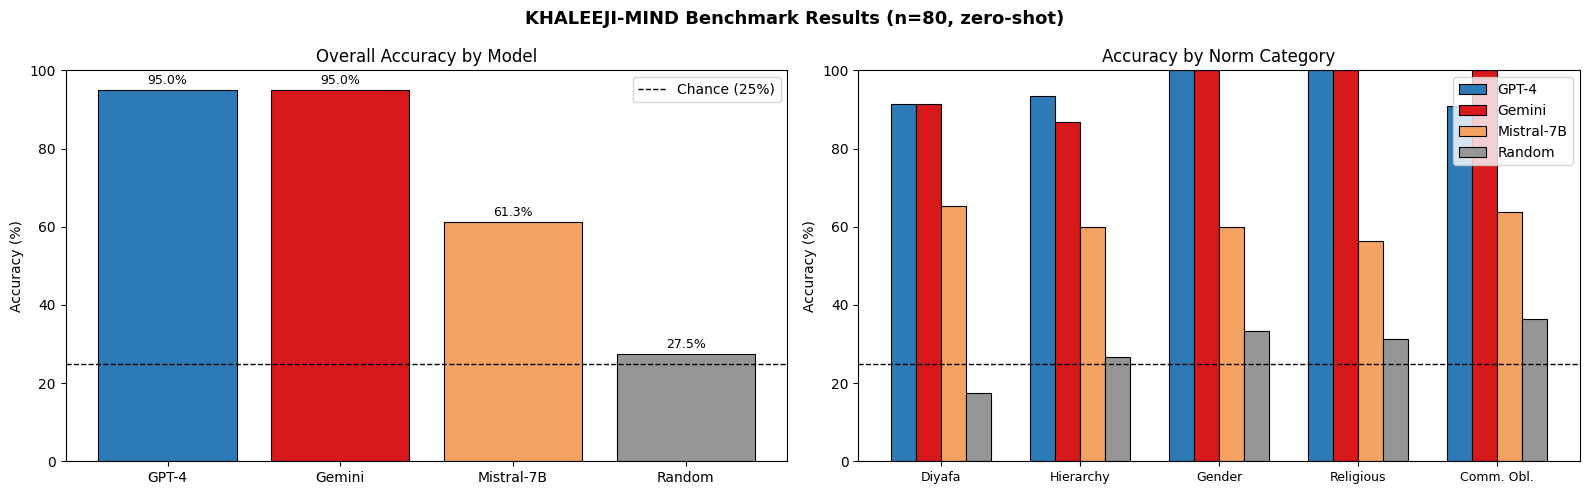

✅ Figure saved as khaleeji_mind_results.png


In [ ]:
import matplotlib.pyplot as plt

MODELS     = ["GPT-4", "Gemini", "Mistral-7B", "Random"]
COLORS     = ["#2c7bb6", "#d7191c", "#f4a261", "#969696"]
CAT_LABELS = ["Diyafa", "Hierarchy", "Gender", "Religious", "Comm. Obl."]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("KHALEEJI-MIND Benchmark Results (n=80, zero-shot)", fontsize=13, fontweight="bold")

# ── Plot 1: Overall accuracy by model ────────────────────────
overall_acc = [all_results[all_results.model == m]["is_correct"].mean() * 100 for m in MODELS]
bars = axes[0].bar(MODELS, overall_acc, color=COLORS, edgecolor="black", linewidth=0.8)
axes[0].axhline(25, color="black", linestyle="--", linewidth=1, label="Chance (25%)")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Overall Accuracy by Model")
axes[0].set_ylim(0, 100)
axes[0].legend()
for bar, v in zip(bars, overall_acc):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 1.5,
                 f"{v:.1f}%", ha="center", fontsize=9)

# ── Plot 2: Per-category accuracy ─────────────────────────────
x     = range(len(CATS))
width = 0.18
for i, (model, color) in enumerate(zip(MODELS, COLORS)):
    m    = all_results[all_results.model == model]
    vals = [
        m[m.norm_category == c]["is_correct"].mean() * 100
        if len(m[m.norm_category == c]) > 0 else 0
        for c in CATS
    ]
    axes[1].bar(
        [xi + i * width for xi in x], vals, width,
        label=model, color=color, edgecolor="black", linewidth=0.8
    )

axes[1].axhline(25, color="black", linestyle="--", linewidth=1)
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy by Norm Category")
axes[1].set_xticks([xi + width * 1.5 for xi in x])
axes[1].set_xticklabels(CAT_LABELS, fontsize=9)
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.savefig("khaleeji_mind_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure saved as khaleeji_mind_results.png")

## Step 9 — Error Analysis

### 9a — Western-Centric Error Rate

Measures how often a model's **wrong answers** specifically land on the **Western-centric distractor** option — the answer that reflects how a non-Khaleeji observer would misread the situation.

A high Western-centric error rate means the model is not just failing randomly; it is systematically defaulting to a Western cultural frame.

### 9b — Accuracy by Severity

Checks whether models perform worse on scenarios with **higher severity scores** — i.e., situations where the social norm violation is more serious and the cultural gap is larger.


In [ ]:
# ── 9a: Western-centric error rate ───────────────────────────
western_map = {row["id"]: row["western_letter"] for _, row in df.iterrows()}

all_results["western_error"] = all_results.apply(
    lambda r: (not r["is_correct"]) and
              (r["predicted"] == western_map.get(r["scenario_id"])),
    axis=1
)

print("Western-centric error rate (% of wrong answers choosing the Western distractor):")
print("-" * 60)
for model in ["GPT-4", "Gemini", "Mistral-7B", "Random"]:
    m     = all_results[all_results.model == model]
    wrong = m[~m["is_correct"]]
    if len(wrong) == 0:
        print(f"  {model:<15}: no errors")
        continue
    rate  = wrong["western_error"].mean() * 100
    count = int(wrong["western_error"].sum())
    print(f"  {model:<15}: {rate:.1f}%  ({count} of {len(wrong)} wrong answers were Western-centric)")

# ── 9b: Accuracy by ToM order ────────────────────────────────
print("\nAccuracy by ToM order:")
print("-" * 40)
for model in ["GPT-4", "Gemini", "Mistral-7B", "Random"]:
    m  = all_results[all_results.model == model]
    o1 = m[m.tom_order == 1]
    o2 = m[m.tom_order == 2]
    print(f"  {model:<15}: Order-1 = {acc(o1):.1f}%  (n={len(o1)})  |  Order-2 = {acc(o2):.1f}%  (n={len(o2)})")

# ── 9c: Accuracy by severity ──────────────────────────────────
print("\nAccuracy by severity level (zero-shot):")
print("-" * 55)
for model in ["GPT-4", "Gemini", "Mistral-7B"]:
    print(f"\n  {model}:")
    m = all_results[(all_results.model == model) & (all_results.condition == "zero_shot")]
    for sev in sorted(m["severity"].dropna().unique()):
        sub = m[m["severity"] == sev]
        print(f"    severity {int(sev)}: {acc(sub):.1f}%  (n={len(sub)})")

Western-centric error rate (% of wrong answers choosing the Western distractor):
------------------------------------------------------------
  GPT-4          : 25.0%  (1 of 4 wrong answers were Western-centric)
  Gemini         : 0.0%  (0 of 4 wrong answers were Western-centric)
  Mistral-7B     : 35.5%  (11 of 31 wrong answers were Western-centric)
  Random         : 17.2%  (10 of 58 wrong answers were Western-centric)

Accuracy by ToM order:
----------------------------------------
  GPT-4          : Order-1 = 92.7%  (n=41)  |  Order-2 = 97.4%  (n=39)
  Gemini         : Order-1 = 92.7%  (n=41)  |  Order-2 = 97.4%  (n=39)
  Mistral-7B     : Order-1 = 65.9%  (n=41)  |  Order-2 = 56.4%  (n=39)
  Random         : Order-1 = 24.4%  (n=41)  |  Order-2 = 30.8%  (n=39)

Accuracy by severity level (zero-shot):
-------------------------------------------------------

  GPT-4:
    severity 0: 100.0%  (n=46)
    severity 2: 100.0%  (n=5)
    severity 3: 84.6%  (n=13)
    severity 4: 88.9%  (n=9)

### Western-Centric Error, ToM, and Severity Analysis

The Western-centric error analysis measures how often a model’s wrong answers matched the option labeled as the likely Western or non-local misunderstanding. This helps distinguish between general mistakes and mistakes that specifically reflect culturally external interpretations.

**Mistral-7B** had the highest Western-centric error rate, with **35.5%** of its wrong answers choosing the Western distractor. This suggests that when Mistral-7B fails, it often defaults to interpretations that align with non-local assumptions about directness, individual preference, or surface-level behavior. **GPT-4** had a much lower Western-centric error rate at **25.0%**, while **Gemini** had **0.0%**, meaning its few errors did not match the predefined Western distractor. The random baseline had **17.2%**, which provides a useful comparison point.

The ToM-order breakdown shows that **GPT-4** and **Gemini** performed better on second-order ToM than first-order ToM, with both achieving **97.4%** on second-order scenarios compared with **92.7%** on first-order scenarios. This suggests that the second-order items were not necessarily harder for frontier models, possibly because many of them made the misunderstanding structure clearer. In contrast, **Mistral-7B** performed better on first-order ToM (**65.9%**) than second-order ToM (**56.4%**), showing that smaller models struggle more when they must reason about one person’s understanding of another person’s belief.

The severity analysis shows that **GPT-4** and **Gemini** answered all severity-0 and severity-2 scenarios correctly, but performance dropped slightly for severity 3–5. This suggests that higher-severity scenarios may involve more subtle or socially consequential breaches, such as disrespecting elders, mishandling qahwa, or violating hospitality expectations. Mistral-7B remained much lower across all severity levels, with especially weak performance on severity 2 and severity 4 scenarios.

Overall, these results show that larger models are highly accurate but still make occasional errors on socially delicate high-severity cases. Mistral-7B is not only less accurate overall, but also more likely to choose culturally external interpretations when it fails.

## Step 10 — Norm-in-Context Diagnostic

A deeper look at the zero-shot vs norm-in-context gap, broken down by norm category for all three models.

- A **large positive boost** (e.g. +13%) → the model lacked the cultural knowledge but could apply it once given. This is Mistral-7B's profile (+13.7pp overall).
- A **near-zero or negative boost** → the model has a persistent reasoning bias that knowledge alone cannot correct. This is GPT-4 (+3.8pp) and Gemini (+1.2pp)'s profile.

The spot-check at the end shows individual failures for each model under norm-in-context, revealing which categories and which Western distractors each model keeps choosing even after being given the correct cultural context.


In [ ]:
# ── Zero-shot vs Norm-in-context comparison ──────────────────
print("=" * 72)
print("ZERO-SHOT vs NORM-IN-CONTEXT ACCURACY")
print("(Large boost → knowledge gap | Small boost → bias / reasoning failure)")
print("=" * 72)
print(f"{'Model':<15} {'Zero-Shot':>10} {'Norm-Context':>13} {'Boost':>8} {'Interpretation':>22}")
print("-" * 72)

for model in ["GPT-4", "Gemini", "Mistral-7B"]:
    zs    = all_results[(all_results.model == model) & (all_results.condition == "zero_shot")]["is_correct"].mean() * 100
    nc    = norm_results[norm_results.model == model]["is_correct"].mean() * 100
    boost = nc - zs
    interp = "Knowledge gap" if boost > 10 else "Bias / reasoning failure"
    print(f"{model:<15} {zs:>9.1f}%  {nc:>12.1f}%  {boost:>+7.1f}%  {interp:>22}")

print("=" * 72)

# ── Per-category norm boost ───────────────────────────────────
print("\nNorm-context boost by category (+ = norm context helped):")
print("-" * 60)
for model in ["GPT-4", "Gemini", "Mistral-7B"]:
    print(f"\n  {model}:")
    for cat in CATS:
        zs = all_results[
            (all_results.model == model) & (all_results.condition == "zero_shot") &
            (all_results.norm_category == cat)
        ]["is_correct"].mean() * 100
        nc = norm_results[
            (norm_results.model == model) & (norm_results.norm_category == cat)
        ]["is_correct"].mean() * 100
        boost = nc - zs
        bar   = "+" * int(abs(boost) // 5) if boost > 0 else "-" * int(abs(boost) // 5)
        print(f"    {cat:<28} {zs:.1f}% → {nc:.1f}%  ({boost:+.1f}%)  {bar}")

ZERO-SHOT vs NORM-IN-CONTEXT ACCURACY
(Large boost → knowledge gap | Small boost → bias / reasoning failure)
Model            Zero-Shot  Norm-Context    Boost         Interpretation
------------------------------------------------------------------------
GPT-4                95.0%          98.8%     +3.8%  Bias / reasoning failure
Gemini               95.0%          96.2%     +1.2%  Bias / reasoning failure
Mistral-7B           61.3%          75.0%    +13.7%           Knowledge gap

Norm-context boost by category (+ = norm context helped):
------------------------------------------------------------

  GPT-4:
    diyafa                       91.3% → 95.7%  (+4.3%)  
    hierarchy                    93.3% → 100.0%  (+6.7%)  +
    gender_interaction           100.0% → 100.0%  (+0.0%)  
    religious_observance         100.0% → 100.0%  (+0.0%)  
    community_obligation         90.9% → 100.0%  (+9.1%)  +

  Gemini:
    diyafa                       91.3% → 95.7%  (+4.3%)  
    hierarchy   

### Zero-Shot vs Norm-in-Context Comparison

This comparison tests whether model accuracy improves when the relevant Emirati cultural norm is explicitly provided before the question. A large improvement suggests a **cultural knowledge gap**, while a small improvement suggests that the model already had access to the relevant cultural knowledge and that remaining errors may come from reasoning, bias, ambiguity, or answer-option confusion.

**GPT-4** improved from **95.0%** in zero-shot to **98.8%** with norm-in-context prompting, a gain of **+3.8%**. Since its zero-shot performance was already very high, the small boost suggests that GPT-4 usually inferred the cultural context correctly without needing explicit explanation. The remaining errors are more likely related to subtle reasoning or ambiguous answer choices.

**Gemini** improved only slightly, from **95.0%** to **96.2%**, a gain of **+1.2%**. This suggests that explicit norm context did not substantially change its performance, meaning Gemini already handled most cultural cues in the zero-shot setting.

**Mistral-7B** showed the largest improvement, rising from **61.3%** to **75.0%**, a boost of **+13.7%**. This indicates a stronger cultural knowledge gap: when Emirati سنع was made explicit, Mistral-7B became much better at identifying the correct interpretation.

At the category level, Mistral-7B benefited most from norm context in **hierarchy** and **diyafa**, improving by **+26.7%** and **+17.4%** respectively. This suggests that these categories contain many culturally specific expectations that smaller models may not infer on their own. GPT-4 also improved in **community obligation** and **hierarchy**, while Gemini showed only a small gain in **diyafa**.

Overall, norm-in-context prompting helped all models, but it helped **Mistral-7B** the most. This supports the idea that smaller models struggle mainly because they lack or fail to retrieve the relevant Emirati cultural knowledge, while frontier models mostly fail only on the most subtle or ambiguous cases.

In [ ]:
# ── Spot-check: norm-in-context failures for all models ───────
norm_map = {row["id"]: row["norm_prompt"] for _, row in df.iterrows()}

norm_by_model = {
    "GPT-4":      norm_gpt4,
    "Gemini":     norm_gemini,
    "Mistral-7B": norm_mistral,
}

for model_name, norm_df in norm_by_model.items():
    failures = norm_df[~norm_df["is_correct"]].head(15)

    print(f"\n{'='*75}")
    print(f"{model_name} norm-in-context failures — what did it answer?")
    print(f"{'='*75}")
    print(f"{'ID':<12} {'Correct':>8} {'Predicted':>10} {'Western?':>10} {'Severity':>9} {'Category':<25}")
    print("-" * 75)

    for _, row in failures.iterrows():
        is_western = row["predicted"] == western_map.get(row["scenario_id"])
        sev_val    = df[df["id"] == row["scenario_id"]]["severity"].values
        sev_str    = str(int(sev_val[0])) if len(sev_val) > 0 else "?"
        print(
            f"{row['scenario_id']:<12} {row['correct']:>8} {str(row['predicted']):>10} "
            f"{'YES' if is_western else 'no':>10} {sev_str:>9} {row['norm_category']:<25}"
        )

    if len(failures) > 0:
        western_fail_rate = failures.apply(
            lambda r: r["predicted"] == western_map.get(r["scenario_id"]), axis=1
        ).mean() * 100
        print(f"\nWestern-centric rate among failures: {western_fail_rate:.1f}%")

        print(f"\nFull example of a {model_name} norm-in-context failure:")
        print("=" * 62)
        fail_id  = failures.iloc[0]["scenario_id"]
        fail_row = df[df["id"] == fail_id].iloc[0]
        print(f"Scenario ID   : {fail_id}")
        print(f"Correct answer: {fail_row['correct']}")
        print(f"{model_name} answered: {failures.iloc[0]['predicted']}")
        print(f"Western distractor letter: {western_map.get(fail_id)}")
        print(f"Severity: {fail_row['severity']}")
        print(f"\nNorm prompt sent:\n{fail_row['norm_prompt']}")


GPT-4 norm-in-context failures — what did it answer?
ID            Correct  Predicted   Western?  Severity Category                 
---------------------------------------------------------------------------
KM_D07              A          C         no         3 diyafa                   

Western-centric rate among failures: 0.0%

Full example of a GPT-4 norm-in-context failure:
Scenario ID   : KM_D07
Correct answer: A
GPT-4 answered: C
Western distractor letter: B
Severity: 3

Norm prompt sent:
Cultural context: Customary Emirati hosting includes small acts of deference by the host. When food is ready, the host may remain standing until the guests move toward the meal and take their seats. The phrase "the food is ready" is not only information; it functions as a cue that guests should begin moving promptly. By continuing the conversation, the cousin unintentionally keeps Mariam standing in her hosting role. The sister-in-law understands this breach, but cannot correct it openly witho

### Norm-in-Context Failure Analysis

The norm-in-context failure analysis shows that explicit cultural context reduced errors substantially, especially for GPT-4 and Gemini. **GPT-4 made only one error**, on KM_D07, while **Gemini made three errors**, on KM_D11, KM_H18, and KM_H19. None of these frontier-model failures were Western-centric, meaning their wrong answers did not match the predefined Western distractor. This suggests that their remaining mistakes were more likely caused by answer-option ambiguity or fine-grained reasoning issues rather than culturally external assumptions.

The GPT-4 failure on **KM_D07** is especially useful as a dataset-quality check. Even after receiving the cultural explanation, GPT-4 selected option C instead of A. Since the model understood that Mariam was standing while waiting for the guests to move toward the meal, this suggests the answer choices may be too close or that the correct answer should be rewritten more directly.

Gemini’s failures also point to subtle ambiguity. In **KM_D11**, it chose A instead of B, which shows that “closest to him socially” and “warmest/natural choice” may overlap too much. In **KM_H18** and **KM_H19**, Gemini selected answers that were culturally plausible but not the intended target, suggesting that these items may need clearer option separation.

Mistral-7B still made more failures under norm-in-context prompting, but its error pattern improved compared with zero-shot. It had a **40.0% Western-centric rate among failures**, meaning some mistakes still reflected non-local interpretations even after cultural context was provided. It also produced several blank predictions, so part of its failure rate may come from formatting or answer-extraction problems rather than reasoning alone.

Overall, norm-in-context prompting strongly reduces cultural-knowledge gaps, especially for Mistral-7B. However, the remaining errors reveal that a few dataset items should be revised to reduce ambiguity, particularly KM_D07, KM_D11, KM_H18, and KM_H19.

## Step 11 — Save Results

Exports the full zero-shot results table to CSV for further analysis or sharing.  
The saved file includes all metadata columns: model, condition, language, norm_category, tom_order, severity, violated_norm, predicted, correct, is_correct, western_error.


In [ ]:
# ── Save all evaluation results ───────────────────────────────
cot_df = pd.concat([cot_gpt4, cot_gemini, cot_mistral], ignore_index=True)

full_results = pd.concat([
    all_results,
    cot_df,
    norm_results
], ignore_index=True)

output_path = "khaleeji_mind_full_results.csv"
full_results.to_csv(output_path, index=False)

print(f"✅ Saved {len(full_results)} rows to '{output_path}'")
print(f"\nCondition breakdown:")
print(full_results.groupby(["model","condition"]).size().to_string())
print(f"\nColumns: {full_results.columns.tolist()}")
print("\nFirst 5 rows:")
full_results.head()

✅ Saved 800 rows to 'khaleeji_mind_full_results.csv'

Condition breakdown:
model       condition       
GPT-4       chain_of_thought    80
            norm_in_context     80
            zero_shot           80
Gemini      chain_of_thought    80
            norm_in_context     80
            zero_shot           80
Mistral-7B  chain_of_thought    80
            norm_in_context     80
            zero_shot           80
Random      zero_shot           80

Columns: ['scenario_id', 'model', 'condition', 'language', 'norm_category', 'tom_order', 'severity', 'violated_norm', 'predicted', 'correct', 'is_correct', 'raw_response', 'western_error']

First 5 rows:


,scenario_id,model,condition,language,norm_category,tom_order,severity,violated_norm,predicted,correct,is_correct,raw_response,western_error
0,KM_C8,Random,zero_shot,EN,community_obligation,1,4,Arriving unannounced during afternoon rest time.,A,C,False,NaN,True
1,KM_D02,Random,zero_shot,EN,diyafa,1,0,Misreading standard Emirati guest reception as...,A,D,False,NaN,True
2,KM_D27,Random,zero_shot,EN,diyafa,2,4,Filling an elder’s qahwa cup too much and mist...,C,A,False,NaN,False
3,KM_D04,Random,zero_shot,EN,diyafa,2,3,Misreading oud or dukhoon after the meal as co...,B,C,False,NaN,True
4,KM_D05,Random,zero_shot,EN,diyafa,1,0,Correctly reading the qahwa cup gestures for r...,B,B,True,NaN,False


### Full Results Export

The full evaluation results were successfully saved to `khaleeji_mind_full_results.csv`. The file contains **800 rows**, which is correct for the full experiment setup: 80 scenarios were evaluated across three conditions for GPT-4, Gemini, and Mistral-7B, while the Random baseline was evaluated only in the zero-shot condition.

The condition breakdown confirms that each model-condition pair contains exactly **80 results**, meaning no scenarios are missing from the exported file. The Random baseline only appears under zero-shot because it does not use prompts, reasoning, or norm-in-context information.

The exported file also preserves the key metadata needed for analysis, including scenario ID, model, condition, language, norm category, ToM order, severity, violated norm, predicted answer, correct answer, correctness, raw model response, and whether the error matched the Western distractor. This makes the file ready for later analysis, visualization, and reporting.

## Known Issues & Next Steps

### Known Issues
- **Single annotator**: inter-annotator agreement cannot be computed yet; all scenarios were written and validated by one author.
- **Jais evaluation**: deferred — HuggingFace Inference API access was unavailable at submission time. Replaced with Mistral-7B-Instruct-v0.1 as open-source baseline. Jais evaluation via T4 GPU is the first Phase 2 priority.
- **Western distractor matching**: the letter-matching heuristic uses word overlap and may occasionally misassign the letter for very short option texts.
- **Construct validity**: many scenarios may be solvable through general social reasoning rather than Gulf-specific cultural knowledge, limiting diagnostic power for frontier models.

### Next Steps
- Expand dataset to 150+ scenarios with adversarial design targeting scenarios where Gulf norms diverge sharply from Western defaults.
- Add IAA certification with at minimum three native Gulf Arabic annotators (Krippendorff's α).
- Evaluate Jais-13B via Colab T4 GPU as Arabic-native baseline.
- Evaluate under 3-shot and 5-shot conditions.
- Conduct human baseline study with Emirati participants (n ≥ 10).
- Release dataset and benchmark publicly on HuggingFace Hub.